# Atividade 04 — Regressão Logística

**Script R equivalente:** [`../scriptsR/04-regressao-logistica.R`](../scriptsR/04-regressao-logistica.R)

**Explicação detalhada (consolidado):** [consolidado/04-regressao-logistica.md](https://github.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/blob/main/consolidado/04-regressao-logistica.md)

**Propósito deste notebook:** permitir a execução desta atividade no Google Colab (runtime R), exibindo todas as saídas e gráficos inline. Diferente do script `.R`, este notebook **não grava arquivos** — não salva `.png` nem relatórios `.md`.

**Alvo binário:** `mortalidade_alta` = 1 se `mortalidade_60_69` > mediana.

**Como rodar no Colab:** `Runtime` → `Change runtime type` → selecionar **R** → `Run all`.


In [1]:
# =============================================================
# SETUP — Atividade 04
# =============================================================
# No Google Colab: Runtime > Change runtime type > R
# Esta atividade nao requer pacotes externos.

options(repr.plot.width = 8, repr.plot.height = 7)

cat("[INFO] Setup concluido.\n")

[INFO] Setup concluido.


In [2]:
# =============================================================
# DADOS — Atividade 04
# =============================================================
arquivo_local <- file.path("..", "bancoDeDados", "df_ipdm_baixada_por_municipio.csv")
url_github    <- "https://raw.githubusercontent.com/Megalonnix/proj_ivan_gustavo_jorge_IPDM/main/estrutura/bancoDeDados/df_ipdm_baixada_por_municipio.csv"

origem_dados <- if (file.exists(arquivo_local)) arquivo_local else url_github
if (file.exists(arquivo_local)) cat("[INFO] Carregando banco LOCAL.\n") else cat("[INFO] Carregando do GitHub.\n")

dados_brutos <- read.csv(origem_dados, sep = ";", dec = ",", fileEncoding = "latin1",
                         check.names = FALSE, stringsAsFactors = FALSE)

dados <- data.frame(
  escolaridade      = as.numeric(dados_brutos[[6]]),
  mortalidade_60_69 = as.numeric(dados_brutos[[8]])
)

mediana_mort <- median(dados$mortalidade_60_69)
dados$mortalidade_alta <- as.integer(dados$mortalidade_60_69 > mediana_mort)
y <- dados$mortalidade_alta; x <- dados$escolaridade

cat("[INFO] Dados carregados:", nrow(dados), "linhas.\n")

[INFO] Carregando banco LOCAL.
[INFO] Dados carregados: 54 linhas.


In [3]:
# =============================================================
# ANALISE — Atividade 04
# =============================================================
m <- glm(mortalidade_alta ~ escolaridade, family = binomial, data = dados)
cat("\n================ MODELO LOGISTICO ================\n")
printCoefmat(coef(summary(m)), signif.legend = FALSE)

b0 <- coef(m)[1]; b1 <- coef(m)[2]
cat("Equacao (logit):", round(b0, 4), "+", round(b1, 4), "x escolaridade\n")
cat("Razao de chances exp(b1) =", round(exp(b1), 4), "\n")
cat("Interpretacao: cada +1 em escolaridade multiplica a chance de",
    "mortalidade alta por", round(exp(b1), 4), ".\n")

esc_ex <- c(0.40, 0.50, 0.60)
logit_ex <- b0 + b1 * esc_ex
odds_ex  <- exp(logit_ex); p_ex <- odds_ex / (1 + odds_ex)
cat("\nTabela logit/odds/p:\n")
print(data.frame(escolaridade = esc_ex, logit = round(logit_ex, 3),
                 odds = round(odds_ex, 3), p = round(p_ex, 3)))

x_estrela <- -b0 / b1
cat("Fronteira de decisao (p = 0.5): x* =", round(x_estrela, 3), "\n")

p <- predict(m, type = "response"); yhat <- as.integer(p > 0.5)
tab <- table(real = y, previsto = yhat)
cat("\nMatriz de confusao (0.5):\n"); print(tab)
VP <- tab["1","1"]; FN <- tab["1","0"]; FP <- tab["0","1"]; VN <- tab["0","0"]
cat("Acuracia:", round(mean(yhat == y), 3), "\n")
cat("Precisao:", round(VP/(VP+FP), 3), "\n")
cat("Recall:  ", round(VP/(VP+FN), 3), "\n")
cat("Espec.:  ", round(VN/(VN+FP), 3), "\n")

cat("\nMatrizes nos limiares 0.3 / 0.5 / 0.7:\n")
for (L in c(0.3, 0.5, 0.7)) {
  cat("\n--- limiar", L, "---\n")
  print(table(real = y, previsto = as.integer(p > L)))
}

ord <- order(p, decreasing = TRUE)
tpr <- cumsum(y[ord]) / sum(y)
fpr <- cumsum(1 - y[ord]) / sum(1 - y)
AUC <- mean(outer(p[y==1], p[y==0], ">"))
cat("\nAUC:", round(AUC, 3), "\n")

youden <- tpr - fpr; pos <- which.max(youden); melhor <- p[ord][pos]
cat("\nYouden - limiar:", round(melhor, 3),
    "| TPR:", round(tpr[pos], 3), "| FPR:", round(fpr[pos], 3), "\n")

yhat_y <- as.integer(p > melhor)
print(table(real = y, previsto = yhat_y))


================ MODELO LOGISTICO ================
             Estimate Std. Error z value Pr(>|z|)
(Intercept)   -1.7776     2.1935 -0.8104   0.4177
escolaridade   3.6486     4.4655  0.8171   0.4139
Equacao (logit): -1.7776 + 3.6486 x escolaridade
Razao de chances exp(b1) = 38.4221 
Interpretacao: cada +1 em escolaridade multiplica a chance de mortalidade alta por 38.4221 .

Tabela logit/odds/p:
  escolaridade  logit  odds     p
1          0.4 -0.318 0.727 0.421
2          0.5  0.047 1.048 0.512
3          0.6  0.412 1.509 0.601
Fronteira de decisao (p = 0.5): x* = 0.487 

Matriz de confusao (0.5):
    previsto
real  0  1
   0 14 13
   1 12 15
Acuracia: 0.537 
Precisao: 0.536 
Recall:   0.556 
Espec.:   0.519 

Matrizes nos limiares 0.3 / 0.5 / 0.7:

--- limiar 0.3 ---
    previsto
real  1
   0 27
   1 27

--- limiar 0.5 ---
    previsto
real  0  1
   0 14 13
   1 12 15

--- limiar 0.7 ---
    previsto
real  0
   0 27
   1 27

AUC: 0.56 

Youden - limiar: 0.477 | TPR: 0.815 | FPR: 0

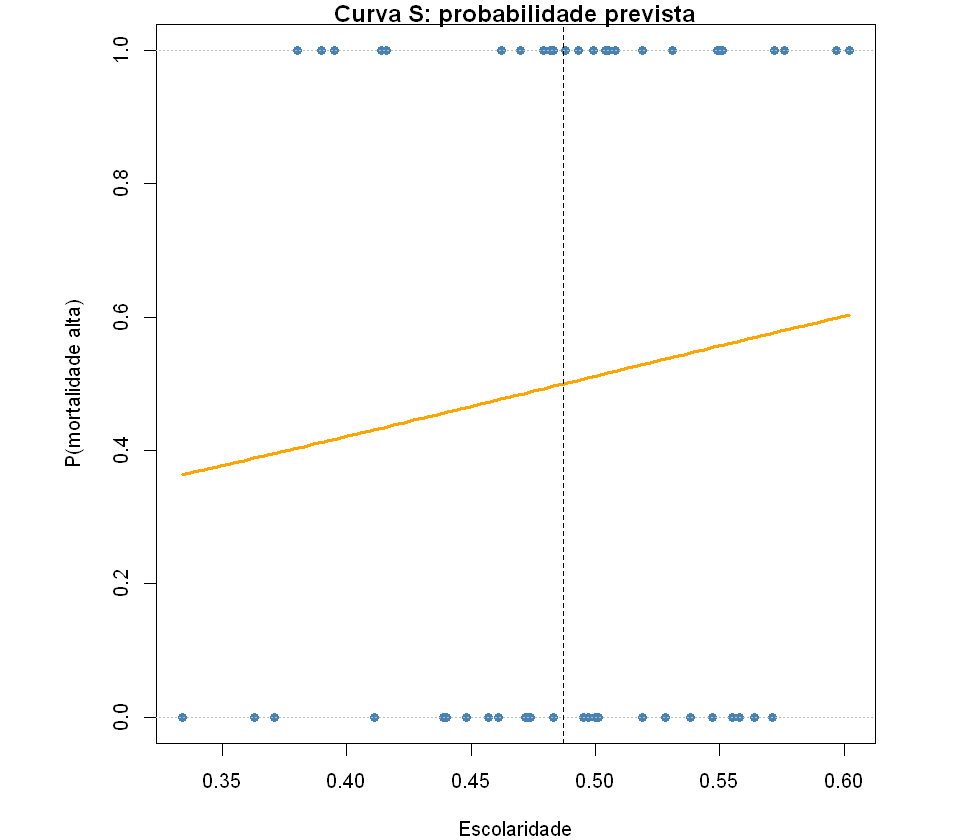

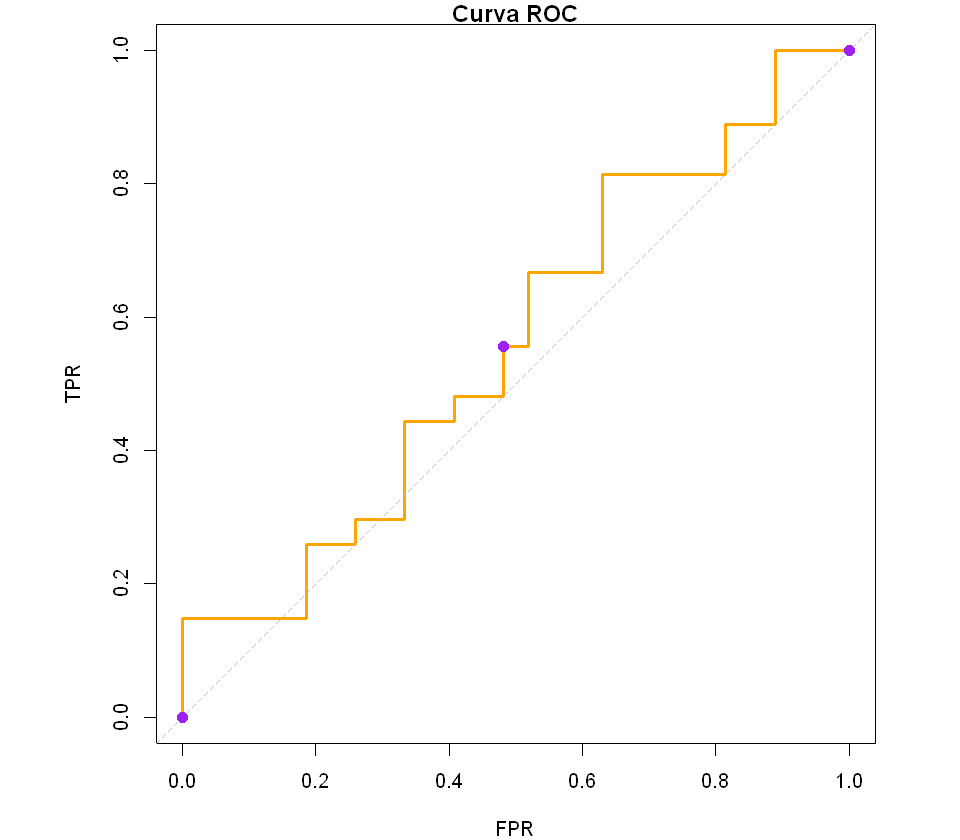

In [4]:
# =============================================================
# GRAFICOS — Atividade 04
# =============================================================
# Grafico 1 — curva sigmoide
par(mar = c(4,4,1,1), pty = "s")
plot(dados$escolaridade, y, pch = 19, col = "steelblue",
     xlab = "Escolaridade", ylab = "P(mortalidade alta)",
     main = "Curva S: probabilidade prevista")
curve(1 / (1 + exp(-(b0 + b1 * x))), add = TRUE, lwd = 3, col = "orange")
abline(h = c(0,1), col = "gray", lty = 3)
abline(v = x_estrela, lty = 2)

# Grafico 2 — curva ROC
par(mar = c(4,4,1,1), pty = "s")
plot(c(0,fpr), c(0,tpr), type = "l", lwd = 3, col = "orange",
     xlab = "FPR", ylab = "TPR", main = "Curva ROC")
abline(0, 1, lty = 2, col = "gray")
for (L in c(0.7, 0.5, 0.3))
  points(mean(p[y==0] > L), mean(p[y==1] > L), pch = 19, cex = 1.2, col = "purple")